# Reflection modulation depth vs substrate conductivity
Input: HFSS Floquet-port reflection export with columns sigma (S/m), frequency (GHz), |S11|.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

CSV_FILE = "TE-R-whole.csv"   # your HFSS reflection export

data = pd.read_csv(CSV_FILE)
data.columns = ["sigma", "freq", "R"]

# Resonance = minimum reflection in the dark state (sigma = 0)
dark = data[data["sigma"] == 0]
idx = dark["R"].idxmin()
f_res = dark["freq"][idx]
r_dark = dark["R"][idx]
print(f"Resonance: {f_res:.1f} GHz, R_dark = {r_dark:.3f}")

Resonance: 300.4 GHz, R_dark = 0.205


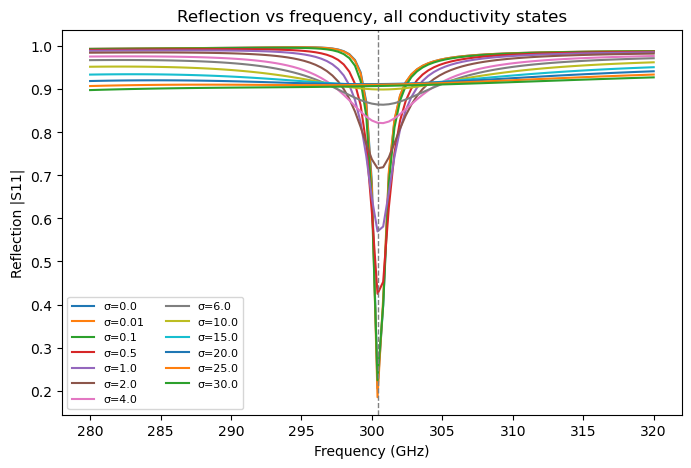

In [2]:
# All conductivity states, resonance marked
plt.figure(figsize=(8, 5))
for s in sorted(data["sigma"].unique()):
    sub = data[data["sigma"] == s]
    plt.plot(sub["freq"], sub["R"], label=f"σ={s}")
plt.axvline(f_res, color="gray", linestyle="--", linewidth=1)
plt.xlabel("Frequency (GHz)")
plt.ylabel("Reflection |S11|")
plt.title("Reflection vs frequency, all conductivity states")
plt.legend(fontsize=8, ncol=2)
plt.show()

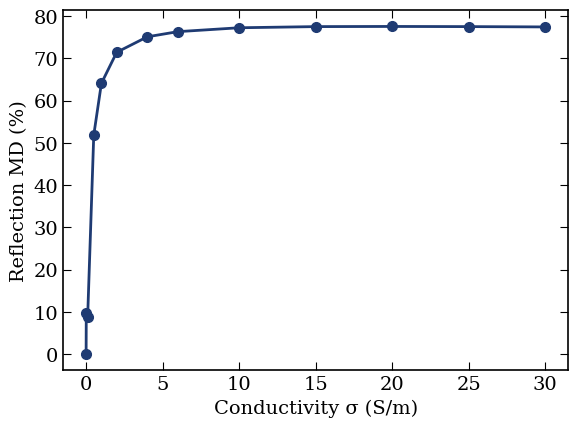

MD at 300.4 GHz, sigma = 25 S/m: 77.5%
Saved MD_vs_sigma.png and .pdf


In [3]:
# Modulation depth at the resonance, relative to the dark state
sigmas, mds = [], []
for s in sorted(data["sigma"].unique()):
    r = data[(data["sigma"] == s) & (data["freq"] == f_res)]["R"].values[0]
    sigmas.append(s)
    mds.append(abs(r - r_dark) / max(r, r_dark) * 100)

plt.rcParams.update({
    "font.size": 14,
    "font.family": "serif",
    "axes.linewidth": 1.2,
    "lines.linewidth": 2,
})
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(sigmas, mds, "o-", color="#1f3b73", markersize=7)
ax.set_xlabel("Conductivity σ (S/m)")
ax.set_ylabel("Reflection MD (%)")
ax.tick_params(direction="in", length=6, top=True, right=True)
fig.tight_layout()
fig.savefig("MD_vs_sigma.png", dpi=300, bbox_inches="tight")
fig.savefig("MD_vs_sigma.pdf", bbox_inches="tight")
plt.show()

if 25 in sigmas:
    print(f"MD at {f_res:.1f} GHz, sigma = 25 S/m: {mds[sigmas.index(25)]:.1f}%")
print("Saved MD_vs_sigma.png and .pdf")